# 06 · Point clouds & white-matter tracts

**SpectralBrain tutorial series — notebook 6 of 10.** (Previous: WKS & GPS.)

Every structure so far was a closed surface mesh. White-matter bundles are
different: a TractSeg segmentation is a *cloud of voxels* with no natural surface
and no faces. This notebook handles geometry without connectivity, using the
**robust (intrinsic) Laplacian**, and introduces the point-cloud spectral
signatures, with the numerical cautions they demand.

### Learning objectives
1. Build an LBO on a point cloud with no faces (the robust Laplacian).
2. Compute HKS / WKS on white-matter bundles from subject 05.
3. Use the point-cloud signatures BKS / iBKS, and respect their numerical limits.
4. Compare bundles by their spectra.


## 1. A Laplacian without faces

The cotangent Laplacian of notebook 1 needs triangles: it sums cotangents of
triangle angles. A point cloud has none. The **robust Laplacian** (Sharp & Crane
2020) solves this by building a local "tufted" triangulation around each point and
defining a Laplace operator on that intrinsic structure. The upshot: any
$N\times 3$ array of points gets a spectrum, eigenfunctions, and therefore every
descriptor in this series, with no meshing step. SpectralBrain selects it
automatically for a `BrainPointCloud`.

> Requires `pip install robust_laplacian`.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import spectralbrain as sb
from _tutorial_utils import data_path

clouds = sb.load_tractseg(data_path("tractseg", "sub05"), output="pointcloud")
print(f"{len(clouds)} white-matter bundles loaded as point clouds.")
for name in ["CA", "SCP_left", "ILF_left", "CST_left"]:
    print(f"  {name:10s}: {clouds[name].points.shape[0]:,} points")

[06/09/26 02:07:25] INFO     TractSeg: 15 bundle masks in                                                          
                             /home/claude/work/spectralbrain-main/tutorials/data/tractseg/sub05/bundle_segmentation
                             s

[06/09/26 02:07:25] INFO     Extracted 47086 points for label 1

                    INFO     Extracted 45527 points for label 1

                    INFO     Extracted 3048 points for label 1

                    INFO     Extracted 302867 points for label 1

...

                    INFO     Extracted 50127 points for label 1

                    INFO     Extracted 13036 points for label 1

                    INFO     Extracted 13591 points for label 1

[06/09/26 02:07:26] INFO     Loaded 15/15 TractSeg bundles as pointcloud.

15 white-matter bundles loaded as point clouds.
  CA        : 3,048 points
  SCP_left  : 13,036 points
  ILF_left  : 17,846 points
  CST_left  : 20,324 points


## 2. Descriptors on a bundle

We take the left corticospinal tract (CST), decompose it, and compute HKS and WKS
exactly as for a mesh. The descriptors flow along the bundle, picking out its
elongated geometry.

[06/09/26 02:07:26] INFO     Point cloud Laplacian (robust): N=20324, nnz=229438

CST_left: 20,324 points -> lambda_1=2.295e-04


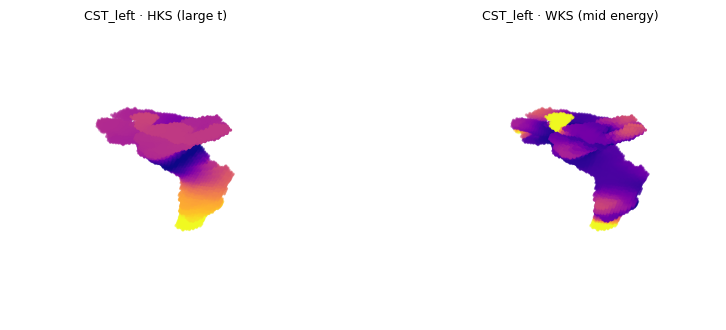

In [2]:
cst = clouds["CST_left"]
dec = cst.decompose(k=60)
hks = np.asarray(sb.compute_hks(dec, n_times=100))
wks = np.asarray(sb.compute_wks(dec, n_energies=100))
print(f"CST_left: {cst.points.shape[0]:,} points -> lambda_1={dec.eigenvalues[1]:.3e}")

P = cst.points
fig = plt.figure(figsize=(9, 3.4))
for i, (desc, t, ttl) in enumerate([(hks, 60, "HKS (large t)"), (wks, 50, "WKS (mid energy)")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    s = desc[:, t]
    ax.scatter(P[:, 0], P[:, 1], P[:, 2], c=s, cmap="plasma", s=2,
               vmin=np.percentile(s, 2), vmax=np.percentile(s, 98))
    ax.set_title(f"CST_left · {ttl}", fontsize=9); ax.set_axis_off(); ax.view_init(15, -75)
plt.tight_layout(); plt.show()

## 3. Point-cloud spectral signatures: BKS and iBKS

Bates et al. (2011) introduced spectral signatures tailored to point clouds for
neuroimaging. SpectralBrain provides the **BKS** (`compute_bks`), its improved
curvature-aware variant **iBKS** (`compute_ibks`), and the multi-time **Bates
signatures** (`compute_bates_signatures`).

**A genuine caution.** BKS can be numerically explosive: on poorly conditioned
clouds its values have been observed to reach $10^{30}$ and beyond, which wrecks
any downstream statistic. Always inspect its range before using it, prefer iBKS
(which is regularised), and exclude BKS if it blows up. We check the range here.

In [3]:
bks  = np.asarray(sb.compute_bks(dec))
ibks = np.asarray(sb.compute_ibks(dec))
bates = np.asarray(sb.compute_bates_signatures(dec, n_times=10))
print(f"BKS   range: {bks.min():.3e} .. {bks.max():.3e}")
print(f"iBKS  range: {ibks.min():.3e} .. {ibks.max():.3e}")
print(f"Bates signatures shape: {bates.shape}")
if bks.max() > 1e6 or not np.isfinite(bks).all():
    print("\n*** BKS is out of safe range here — exclude it from statistics. ***")
else:
    print("\nBKS is within a usable range for this bundle (still prefer iBKS for robustness).")

Output()

BKS   range: 3.059e+01 .. 1.248e+03
iBKS  range: 3.059e+01 .. 1.248e+03
Bates signatures shape: (20324, 20)

BKS is within a usable range for this bundle (still prefer iBKS for robustness).


## 4. Comparing bundles by their spectra

Because the spectrum is pose- and size-normalisable (notebook 3), we can compare
*different bundles* by their ShapeDNA. We decompose a set of bilateral tracts and
cluster them. Bundles that are geometrically alike (left/right of the same tract)
should land near each other.

  CST_left    decomposed (20,324 pts)


[06/09/26 02:07:37] INFO     Point cloud Laplacian (robust): N=19332, nnz=214356

  CST_right   decomposed (19,332 pts)


[06/09/26 02:07:40] INFO     Point cloud Laplacian (robust): N=13036, nnz=147996

  SCP_left    decomposed (13,036 pts)


...

  SCP_right   decomposed (13,591 pts)


[06/09/26 02:07:45] INFO     Point cloud Laplacian (robust): N=17846, nnz=195718

  ILF_left    decomposed (17,846 pts)


[06/09/26 02:07:48] INFO     Point cloud Laplacian (robust): N=16753, nnz=183537

  ILF_right   decomposed (16,753 pts)


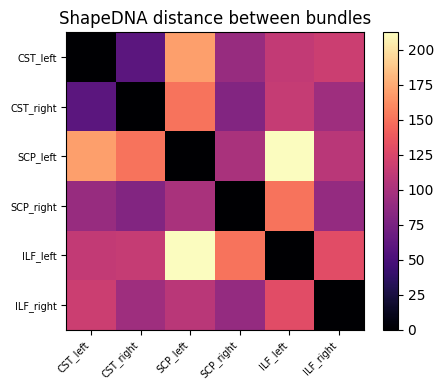

In [4]:
subset = ["CST_left", "CST_right", "SCP_left", "SCP_right", "ILF_left", "ILF_right"]
dnas = {}
for name in subset:
    d = clouds[name].decompose(k=40)
    dnas[name] = sb.compute_shapedna(d, normalize="area")
    print(f"  {name:11s} decomposed ({clouds[name].points.shape[0]:,} pts)")

D = np.zeros((len(subset), len(subset)))
for i, a in enumerate(subset):
    for j, b in enumerate(subset):
        D[i, j] = sb.shapedna_distance(dnas[a], dnas[b])

fig, ax = plt.subplots(figsize=(4.8, 4.0))
im = ax.imshow(D, cmap="magma")
ax.set_xticks(range(len(subset))); ax.set_yticks(range(len(subset)))
ax.set_xticklabels(subset, rotation=45, ha="right", fontsize=7); ax.set_yticklabels(subset, fontsize=7)
ax.set_title("ShapeDNA distance between bundles"); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

## 5. The same bundle, as a mesh

For comparison, load CST as a marching-cubes **mesh** (cotangent Laplacian) and
render its HKS with the six-view tool, the surface counterpart of the point-cloud
scatter above.

[06/09/26 02:07:51] INFO     TractSeg: 15 bundle masks in                                                          
                             /home/claude/work/spectralbrain-main/tutorials/data/tractseg/sub05/bundle_segmentation
                             s

[06/09/26 02:07:53] INFO     Loaded 15/15 TractSeg bundles as mesh.

[06/09/26 02:07:53] INFO     Laplacian (cotangent): N=11379, nnz=79677

2026-06-09 02:07:54.857 (   0.282s) [    7FAD82AD6080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


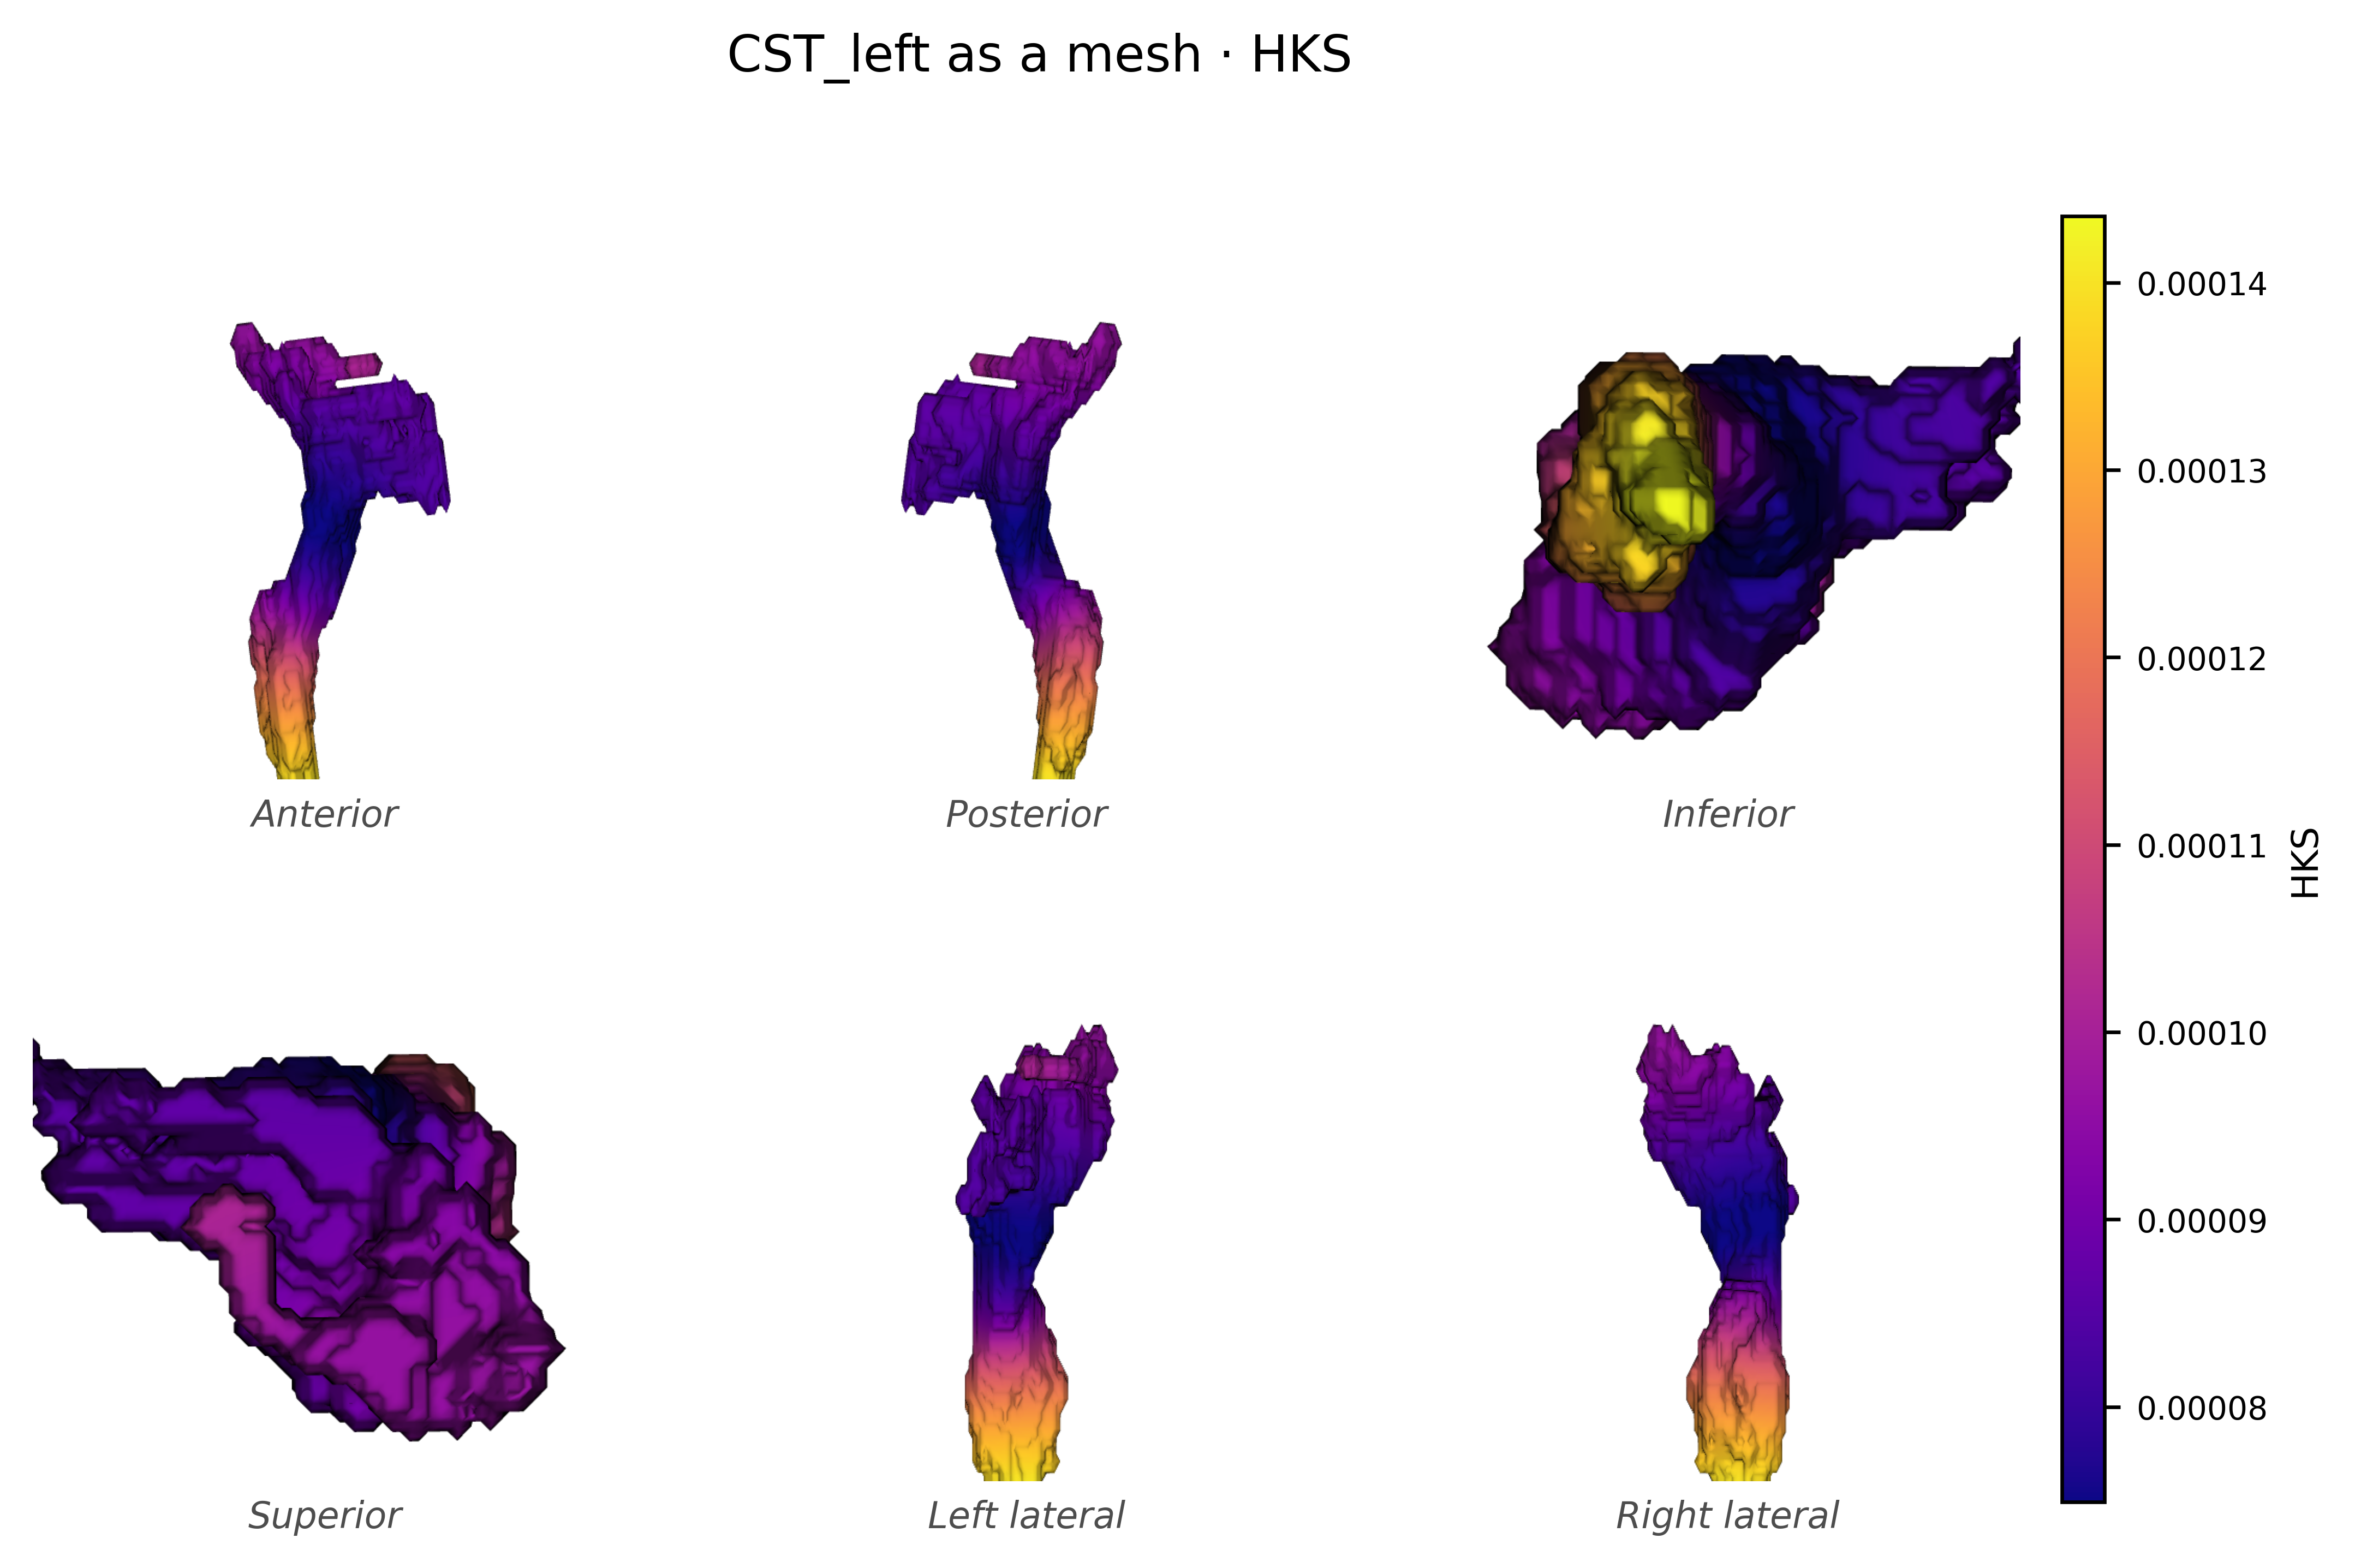

In [5]:
from spectralbrain.viz import plot_surface_sixview
cst_mesh = sb.load_tractseg(data_path("tractseg", "sub05"), output="mesh")["CST_left"]
dm = cst_mesh.decompose(k=60)
hks_m = np.asarray(sb.compute_hks(dm, n_times=100))
fig = plot_surface_sixview(cst_mesh, scalars=hks_m[:, 60], cmap="plasma",
                           scalar_bar_title="HKS", title="CST_left as a mesh · HKS")
plt.show()

## Exercises

1. **Resolution.** The corpus callosum (`CC`) has ~300k points. Decompose it with
   `k=40` and time it. Why is the robust Laplacian on a large cloud expensive, and
   what would you downsample to?
2. **iBKS vs BKS.** Plot BKS and iBKS along the CST. Where do they disagree, and
   which looks more physically plausible (smooth along the bundle)?
3. **Bilateral symmetry.** From the distance matrix, is each tract closer to its
   contralateral twin than to other tracts? Quantify it.
4. **Mesh vs cloud spectra.** Overlay the first 40 eigenvalues of `CST_left` as a
   point cloud and as a mesh. Where do they diverge, and why might that be?
5. **A small bundle.** Decompose the anterior commissure (`CA`, ~3k points) and
   check whether `k=40` is even well-defined for so few points.


## What's next

We can now describe any surface or cloud. **Notebook 07** asks how to *relate two
shapes*: functional maps that transfer information between hippocampi, intrinsic
distances *within* a shape (biharmonic, commute-time, diffusion), and point-set
distances *between* shapes (Chamfer, Hausdorff).
